Steam Store file loaded: Steam Store Games (Clean dataset)\steam.csv
Games Dataset: (122611, 39)
Video Game Sales Dataset: (16598, 11)
Steam Store Dataset: (27075, 18)


,appid,name,release_date,estimated_owners,peak_ccu,required_age,price,discountdlc_count,about_the_game,supported_languages,...,average_playtime_two_weeks,median_playtime_forever,median_playtime_two_weeks,developers,publishers,categories,genres,tags,screenshots,movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


,price,positive,negative,recommendations,average_playtime_forever,peak_ccu
price,1.000000,0.027594,0.016686,0.038753,0.003890,0.080840
positive,0.027594,1.000000,0.818396,0.901769,0.021641,0.090763
negative,0.016686,0.818396,1.000000,0.742785,0.021422,0.092754
recommendations,0.038753,0.901769,0.742785,1.000000,0.018604,0.130522
average_playtime_forever,0.003890,0.021641,0.021422,0.018604,1.000000,0.005578
peak_ccu,0.080840,0.090763,0.092754,0.130522,0.005578,1.000000


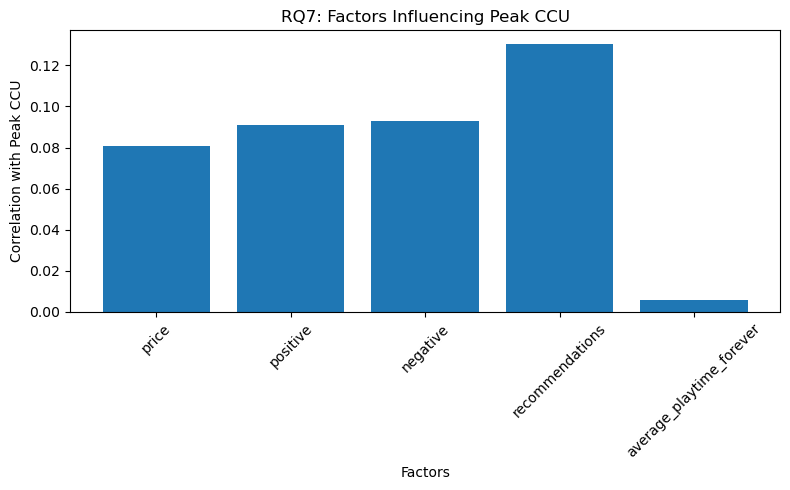

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs("Figures", exist_ok=True)
os.makedirs("Tables", exist_ok=True)


games_df = pd.read_csv("Steam Games Dataset/games.csv", low_memory=False)
vgsales_df = pd.read_csv("Video Game Sales/vgsales.csv", low_memory=False)

# Auto-load Steam Store dataset
steam_files = glob.glob("Steam Store Games (Clean dataset)/*.csv")

if len(steam_files) > 0:
    steam_store_df = pd.read_csv(steam_files[0], low_memory=False)
    print("Steam Store file loaded:", steam_files[0])
else:
    steam_store_df = pd.DataFrame()
    print("Steam Store CSV not found.")


for df in [games_df, vgsales_df, steam_store_df]:
    if not df.empty:
        df.columns = (
            df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ", "_")
            .str.replace("-", "_")
        )

print("Games Dataset:", games_df.shape)
print("Video Game Sales Dataset:", vgsales_df.shape)
print("Steam Store Dataset:", steam_store_df.shape)

display(games_df.head())
display(vgsales_df.head())
display(steam_store_df.head())

rq7 = games_df[
    ['price', 'positive', 'negative', 'recommendations',
     'average_playtime_forever', 'peak_ccu']
].copy()

for col in rq7.columns:
    rq7[col] = pd.to_numeric(rq7[col], errors='coerce')

rq7 = rq7.dropna()

rq7_table = rq7.corr()
rq7_table.to_csv("Tables/RQ7_peak_ccu_factors.csv")

display(rq7_table)

peak_corr = rq7_table['peak_ccu'].drop('peak_ccu')

plt.figure(figsize=(8,5))
plt.bar(peak_corr.index, peak_corr.values)
plt.title("RQ7: Factors Influencing Peak CCU")
plt.xlabel("Factors")
plt.ylabel("Correlation with Peak CCU")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Figures/RQ7_peak_ccu_factors.png")
plt.show()
